DataSet Provided by:
1. https://www.kaggle.com/code/faber24/face-anti-spoofing-detection-using-mobilenetv2/input
2. https://csit.am/2019/proceedings/PRIP/PRIP3.pdf

Workflow Inspiration
1. https://www.kaggle.com/code/faber24/face-anti-spoofing-detection-using-mobilenetv2/notebook

In [9]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
import pydot

import shutil

# Import Data

In [10]:
RAW_KEY = "RAW_DATA_PATH="
TRAIN_FOLDER = "LCC_FASD_training"
VAL_FOLDER = "LCC_FASD_development"
TEST_FOLDER = "LCC_FASD_evaluation"


def find_project_root(start_path: Path | None = None) -> Path:
    current_path = start_path or Path.cwd()

    for path in [current_path, *current_path.parents]:
        if (path / ".gitignore").exists():
            return path

    raise FileNotFoundError("Could not find .gitignore. Check your notebook working directory.")


def get_raw_data_path_from_gitignore() -> Path:
    project_root = find_project_root()
    gitignore_path = project_root / ".gitignore"

    lines = gitignore_path.read_text(encoding="utf-8").splitlines()

    raw_line = next(
        (line.strip() for line in lines if line.strip().startswith(RAW_KEY)),
        ""
    )

    raw_path = raw_line.removeprefix(RAW_KEY).strip()

    if not raw_path:
        raise ValueError("Missing RAW_DATA_PATH in .gitignore.")

    raw_path = Path(raw_path).expanduser()

    if not raw_path.is_absolute():
        raw_path = project_root / raw_path

    return raw_path.resolve()


def get_data_dirs() -> tuple[Path, Path, Path]:
    raw_data_dir = get_raw_data_path_from_gitignore()

    return (
        raw_data_dir / TRAIN_FOLDER,
        raw_data_dir / VAL_FOLDER,
        raw_data_dir / TEST_FOLDER,
    )


train_dir, val_dir, test_dir = get_data_dirs()

print("Train dir:", train_dir)
print("Validation dir:", val_dir)
print("Test dir:", test_dir)

print("Train exists:", train_dir.exists())
print("Validation exists:", val_dir.exists())
print("Test exists:", test_dir.exists())

Train dir: C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_training
Validation dir: C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_development
Test dir: C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation
Train exists: True
Validation exists: True
Test exists: True


# Understanding the Data

In [11]:
#Define Dataset Properties
# Image size for MobileNetV2 input; load train/val splits and preview one batch.
IMG_SIZE = (160, 160)
IMG_SHAPE = IMG_SIZE + (3,)

#Train Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=True
)

#Validation Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=False
)

#Test Set
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=False
)

def get_class_counts(dataset):
    class_counts = {class_name: 0 for class_name in dataset.class_names}
    for path in dataset.file_paths:
        class_name = os.path.basename(os.path.dirname(path))
        if class_name in class_counts:
            class_counts[class_name] += 1
    return class_counts

train_counts = get_class_counts(train_ds)
val_counts = get_class_counts(val_ds)
test_counts = get_class_counts(test_ds)

summary_rows = []
for split_name, dataset, class_counts in [
    ("Train", train_ds, train_counts),
    ("Validation", val_ds, val_counts),
    ("Test", test_ds, test_counts),
]:
    row = {
        "Split": split_name,
        "Total Files": len(dataset.file_paths),
        "Num Classes": len(dataset.class_names),
    }
    for class_name in dataset.class_names:
        row[f"{class_name} Count"] = class_counts.get(class_name, 0)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


Found 8299 files belonging to 2 classes.
Found 2948 files belonging to 2 classes.
Found 7580 files belonging to 2 classes.
     Split  Total Files  Num Classes  real Count  spoof Count
     Train         8299            2        1223         7076
Validation         2948            2         405         2543
      Test         7580            2         314         7266


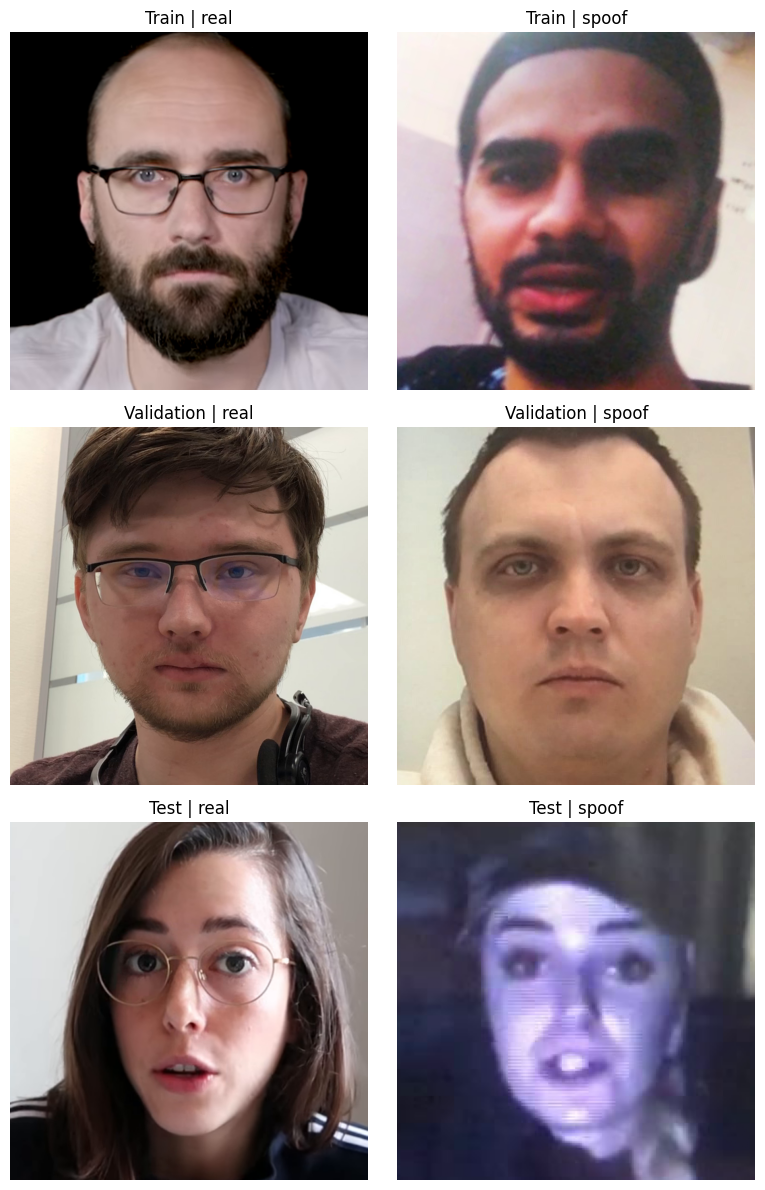

Saved image: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\data_preview.png


In [12]:
datasets = [
    ("Train", train_ds),
    ("Validation", val_ds),
    ("Test", test_ds),
]

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for row, (split_name, dataset) in enumerate(datasets):
    for col, class_name in enumerate(dataset.class_names[:2]):
        class_paths = [
            path for path in dataset.file_paths
            if os.path.basename(os.path.dirname(path)) == class_name
        ]

        ax = axes[row, col]

        if class_paths:
            image_path = np.random.choice(class_paths)
            image = plt.imread(image_path)

            ax.imshow(image, cmap="gray")
            ax.set_title(f"{split_name} | {class_name}")
        else:
            ax.set_title(f"{split_name} | {class_name} (no image)")

        ax.axis("off")

plt.tight_layout()

output_path = Path.cwd() / "data_preview.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved image: {output_path}")

# Define Save Model Location

In [13]:
MODEL_DIR = Path.cwd() / "model"
MODEL_DIR.mkdir(exist_ok=True)

print("Model folder:", MODEL_DIR)

Model folder: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model


# Data Augmentation // Blanked out for now (can implement later if need)

In [14]:
#Define Data Augmentation - Do not use for now

#data_augmentation = tf.keras.Sequential([
#    tf.keras.layers.RandomFlip('horizontal'),
#    tf.keras.layers.RandomRotation(0.2),
#])

In [15]:
# Visualize several random augmentations applied to one image (same pipeline as training).
#for image, _ in train_ds.take(1):
#    plt.figure(figsize=(10, 10))
#    first_image = image[0]
#    for i in range(9):
#        ax = plt.subplot(3, 3, i + 1)
#        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
#        plt.imshow(augmented_image[0].numpy().astype("uint8"))
#        plt.axis('off')
#
#plt.tight_layout()
#plt.show()

In [16]:
# Halt if val_loss stops improving; restore weights from the best epoch.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [17]:
# Use the specific preprocessing function required for MobileNetV2 (scales pixel values to [-1, 1])
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [18]:
# Create the base model from the pre-trained model MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

image_batch, label_batch = next(iter(train_ds))
feature_batch = base_model(preprocess_input(image_batch))
print(feature_batch.shape)

(32, 5, 5, 1280)


In [19]:
# Freeze the convolutional base
base_model.trainable = False
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# Convert the 5x5 spatial features into a single 1280-element feature vector per image
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [21]:
num_classes = len(train_ds.class_names)

prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 2)


In [22]:
# Build the final model architecture
inputs = tf.keras.Input(shape=(160, 160, 3))
#x = data_augmentation(inputs)
x = preprocess_input(inputs)
x = base_model(x, training=False)  # Ensure base model runs in inference mode
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x) # Add dropout for regularization
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)

In [23]:
# Full model: data flow, layer types, and parameter counts.
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
# While the backbone is frozen, only the new top layers contribute trainable weights.
print(len(model.trainable_variables))


2


In [25]:
#Model Architecture Diagram

#Save Architecture
architecture_path = MODEL_DIR / "model_architecture.png"

tf.keras.utils.plot_model(
    model,
    to_file=architecture_path,
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)

print(f"Saved model architecture graph: {architecture_path}")

Saved model architecture graph: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\model_architecture.png


In [26]:
# Configure the model for training
base_learning_rate = 5e-5
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

initial_epochs = 10

In [27]:
# Sanity check on the validation set before any gradient updates.
initial_loss, initial_acc = model.evaluate(val_ds)
print("Initial:")
print("Accuracy: {:.4f}".format(initial_acc))
print("Loss: {:.4f}".format(initial_loss))


93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.2378 - loss: 1.2493
Initial:
Accuracy: 0.2378
Loss: 1.2493


In [28]:
#Get class weight

train_counts = get_class_counts(train_ds)
print(train_counts)
print(train_ds.class_names)

total = sum(train_counts.values())
num_classes = len(train_counts)

class_weight = {
    i: total / (num_classes * train_counts[class_name])
    for i, class_name in enumerate(train_ds.class_names)
}

print(class_weight)

{'real': 1223, 'spoof': 7076}
['real', 'spoof']
{0: 3.392886345053148, 1: 0.5864188807235726}


In [29]:
# Train the model using the frozen base
history = model.fit(
    train_ds,
    epochs=initial_epochs,
    validation_data=val_ds,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step - accuracy: 0.5042 - loss: 0.8167 - val_accuracy: 0.6136 - val_loss: 0.6652
Epoch 2/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 29s 111ms/step - accuracy: 0.6160 - loss: 0.6798 - val_accuracy: 0.6818 - val_loss: 0.5824
Epoch 3/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - accuracy: 0.6824 - loss: 0.5941 - val_accuracy: 0.6923 - val_loss: 0.5615
Epoch 4/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 31s 121ms/step - accuracy: 0.7230 - loss: 0.5401 - val_accuracy: 0.6991 - val_loss: 0.5467
Epoch 5/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - accuracy: 0.7545 - loss: 0.4997 - val_accuracy: 0.7086 - val_loss: 0.5344
Epoch 6/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 33s 126ms/step - accuracy: 0.7680 - loss: 0.4801 - val_accuracy: 0.7110 - val_loss: 0.5250
Epoch 7/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 33s 125ms/step - accuracy: 0.7894 - loss: 0.4437 - val_accuracy: 0.7439 - val_loss: 0.4831
Epoch 8/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 33s 125ms/step - accuracy: 0.7937 - loss: 0

Text(0.5, 1.0, 'Training and Validation Accuracy')

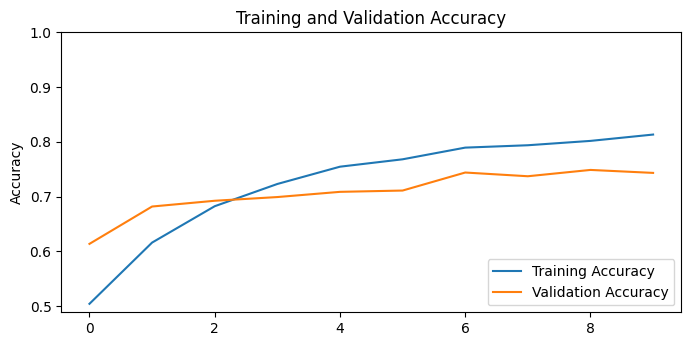

In [30]:
# Extract training results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Visualize training and validation metrics
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

In [31]:
# Evaluate feature extraction model before fine-tuning
feature_loss, feature_acc = model.evaluate(val_ds)

print("Feature Extraction:")
print("Accuracy: {:.4f}".format(feature_acc))
print("Loss: {:.4f}".format(feature_loss))

93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.7486 - loss: 0.4770
Feature Extraction:
Accuracy: 0.7486
Loss: 0.4770


# Fine Tuning

In [32]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

In [33]:
# MobileNetV2 depth — used to choose where fine-tuning starts.
print("Number of layers in the base model: ", len(base_model.layers))


Number of layers in the base model:  154


In [34]:
# Layers below this index stay frozen; deeper layers adapt to your classes.
fine_tune_at = 140


In [35]:
# Keep the first 'fine_tune_at' layers frozen to preserve general features
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [36]:
# Recompile with a lower learning rate for fine-tuning
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

In [37]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 1,042,562 (3.98 MB)

 Non-trainable params: 1,217,984 (4.65 MB)

In [38]:
# After selective unfreezing, more layers (and weights) are trainable.
len(model.trainable_variables)


17

In [39]:
# Continue training the model
fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=len(history.epoch),
    validation_data=val_ds,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 11/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - accuracy: 0.7365 - loss: 0.4535 - val_accuracy: 0.7934 - val_loss: 0.4244
Epoch 12/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 142ms/step - accuracy: 0.8255 - loss: 0.3631 - val_accuracy: 0.8511 - val_loss: 0.3540
Epoch 13/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.8636 - loss: 0.3068 - val_accuracy: 0.8874 - val_loss: 0.2878
Epoch 14/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.8841 - loss: 0.2605 - val_accuracy: 0.8976 - val_loss: 0.2604
Epoch 15/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 142ms/step - accuracy: 0.9107 - loss: 0.2210 - val_accuracy: 0.9054 - val_loss: 0.2414
Epoch 16/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 141ms/step - accuracy: 0.9226 - loss: 0.1963 - val_accuracy: 0.9094 - val_loss: 0.2305
Epoch 17/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 36s 138ms/step - accuracy: 0.9346 - loss: 0.1724 - val_accuracy: 0.9128 - val_loss: 0.2209
Epoch 18/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 36s 139ms/step - accuracy: 0.9467 -

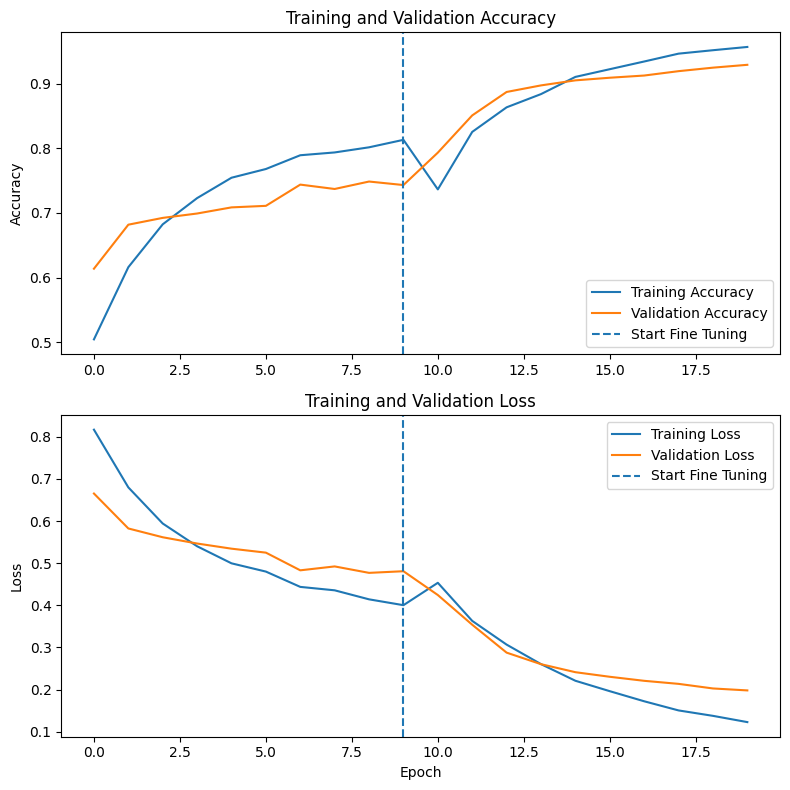

Saved training graph: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\training_graph.png


In [40]:
# Combine histories and plot learning curves before and after fine-tuning
full_acc = history.history["accuracy"] + history_fine.history["accuracy"]
full_val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

full_loss = history.history["loss"] + history_fine.history["loss"]
full_val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

training_graph_path = MODEL_DIR / "training_graph.png"

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.plot(full_acc, label="Training Accuracy")
plt.plot(full_val_acc, label="Validation Accuracy")
plt.axvline(initial_epochs - 1, linestyle="--", label="Start Fine Tuning")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.ylabel("Accuracy")

plt.subplot(2, 1, 2)
plt.plot(full_loss, label="Training Loss")
plt.plot(full_val_loss, label="Validation Loss")
plt.axvline(initial_epochs - 1, linestyle="--", label="Start Fine Tuning")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.tight_layout()
plt.savefig(training_graph_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved training graph: {training_graph_path}")

In [41]:
# 3) Fine-tuned evaluation
fine_tune_loss, fine_tune_acc = model.evaluate(val_ds)
print("\nFine-Tuning:")
print("Accuracy: {:.4f}".format(fine_tune_acc))
print("Loss: {:.4f}".format(fine_tune_loss))

93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9294 - loss: 0.1981

Fine-Tuning:
Accuracy: 0.9294
Loss: 0.1981


In [42]:
print("\nStage\t\t\tAccuracy\tLoss")
print("Initial\t\t\t{:.4f}\t\t{:.4f}".format(initial_acc, initial_loss))
print("Feature Extraction\t{:.4f}\t\t{:.4f}".format(feature_acc, feature_loss))
print("Fine-Tuning\t\t{:.4f}\t\t{:.4f}".format(fine_tune_acc, fine_tune_loss))


Stage			Accuracy	Loss
Initial			0.2378		1.2493
Feature Extraction	0.7486		0.4770
Fine-Tuning		0.9294		0.1981


In [43]:
#Test df
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

237/237 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - accuracy: 0.9449 - loss: 0.1585
Test Accuracy: 0.9448548555374146
Test Loss: 0.15854188799858093


237/237 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step


<Figure size 600x600 with 0 Axes>

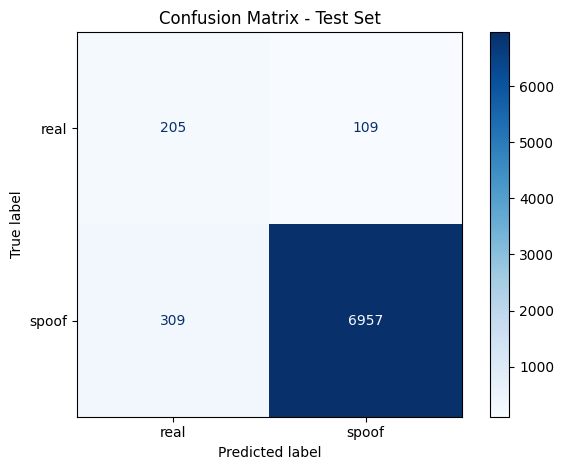

Saved confusion matrix: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\confusion_matrix.png
              precision    recall  f1-score   support

        real       0.40      0.65      0.50       314
       spoof       0.98      0.96      0.97      7266

    accuracy                           0.94      7580
   macro avg       0.69      0.81      0.73      7580
weighted avg       0.96      0.94      0.95      7580



In [48]:
#Create Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get true labels from test dataset
y_true = np.concatenate([labels.numpy() for images, labels in test_ds])

# Get model predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Use class names from training set
class_names = train_ds.class_names

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Save confusion matrix image
confusion_matrix_path = MODEL_DIR / "confusion_matrix.png"

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix: {confusion_matrix_path}")

# Optional: print classification report
print(classification_report(y_true, y_pred, target_names=class_names))

In [44]:
#Save Model
model_path = MODEL_DIR / "fasd_mobilenetv2_model.keras"

model.save(model_path)

print(f"Saved model: {model_path}")

Saved model: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\fasd_mobilenetv2_model.keras


# Test on manually added images

In [45]:
IMG_SIZE = (160, 160)  # same as your training cell

def predict_real_or_spoof(image_path, model, class_names):
    # Load and preprocess
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    x = tf.keras.utils.img_to_array(img)
    x = tf.expand_dims(x, axis=0)  # (1, 160, 160, 3)

    # Predict
    pred = model.predict(x, verbose=0)

    # Works for both binary and softmax outputs
    if pred.shape[-1] == 1:
        # binary output
        score = float(pred[0][0])
        pred_idx = 1 if score >= 0.5 else 0
        confidence = score if pred_idx == 1 else (1 - score)
    else:
        # multi-class output
        pred_idx = int(np.argmax(pred[0]))
        confidence = float(np.max(pred[0]))

    label = class_names[pred_idx]

    # Display
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2%})")
    plt.show()

    print("Raw prediction:", pred)
    print(f"Detected as: {label} | Confidence: {confidence:.2%}")

    return label, confidence

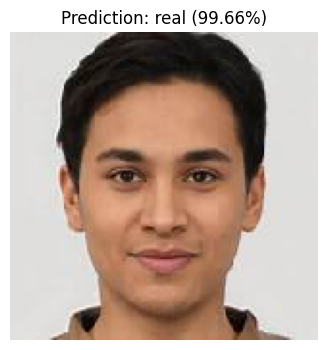

Raw prediction: [[0.9965829  0.00341715]]
Detected as: real | Confidence: 99.66%


('real', 0.9965829253196716)

In [46]:
class_names = train_ds.class_names
image_path = "./Test.jpg"
predict_real_or_spoof(image_path, model, class_names)

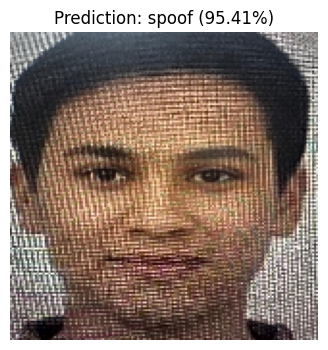

Raw prediction: [[0.04591313 0.95408684]]
Detected as: spoof | Confidence: 95.41%


('spoof', 0.9540868401527405)

In [47]:
class_names = train_ds.class_names  # usually ['real', 'spoof']
image_path = "./Test2.jpeg"
predict_real_or_spoof(image_path, model, class_names)